# Example: Forward modeling RIC, AMR and NAM on the LRGs autocorrelation

This example notebook was run on a shared GPU node at NERSC (one GPU). 

Forward model timing printed by TQDM is overestimated due to compilation time at the first run. Actual timings range from 1.5s to 2.0s per spectra.

In [1]:
import itertools
import os
from pathlib import Path

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.9"

import healpy as hp
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import lsstypes as lss
import matplotlib.pyplot as plt
import numpy as np
from jaxpower import BinMesh2SpectrumPoles, FKPField, compute_fkp2_normalization, get_mesh_attrs
from tqdm import tqdm

from desiwinds.convenience import fiducial_planck_2018, get_randoms, get_sysmap, split_into_fields
from desiwinds.forward import mock_survey_catalog, prepare_AMR, prepare_NAM, prepare_RIC


## Parameters
Adjust data paths and redshift ranges to match your environment.

In [2]:
LOS = "local"
UNITARY_AMPLITUDE = True
nreal_fw = 20

n_randoms = 1

boxsize = 8000.0
cellsize = 20.0

tracer = "LRG"
z_range = (0.4, 1.1) # (0.4, 0.8)  # Thin-ish slice to speed up the example (limited compute resources)

pk_regions = ["SGC", "NGC"]
photo_regions = ["N", "S"]  # Photometric regions for LRG
z_ranges = [(0.4, 0.5), (0.5, 0.6), (0.6, 0.7), (0.7, 0.8), (0.8, 0.9), (0.9, 1.0), (1.0, 1.1)]  # Redshift ranges for the angular systematics regression

data_to_randoms = 0.3 # Use 30% of the randoms catalogs as "data" and the rest as randoms

regression_maps = [
    "STARDENS",
    "PSFSIZE_G",
    "PSFSIZE_R",
    "PSFSIZE_Z",
    "GALDEPTH_G",
    "GALDEPTH_R",
    "GALDEPTH_Z",
    "HI",
    "PSFDEPTH_W1",
    "EBV_DIFF_GR",
    "EBV_DIFF_RZ",
]  # LRG templates

nside_nam = 256

randoms_basedir = Path("/dvs_ro/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v2/fNL")
templates_dir = Path("/dvs_ro/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v2/hpmaps/")
ebvdir = Path("/dvs_ro/cfs/cdirs/desicollab/users/rongpu/data/ebv/desi_stars_y3/v0.1/final_maps/lss/")

## Load randoms and create catalogs

### Imaging templates

In [3]:
sysmaps_south = get_sysmap(
    map_path=Path(
        templates_dir / f"{tracer}_mapprops_healpix_nested_nside256_S.fits"
    ),
    region="S",
    ebv_path=ebvdir / "desi_ebv_lss_256.fits",
)
sysmaps_south.keep_columns(regression_maps)
sysmaps_south = np.lib.recfunctions.structured_to_unstructured(
    sysmaps_south.as_array()
).astype(float)

sysmaps_north = get_sysmap(
    map_path=Path(
        templates_dir / f"{tracer}_mapprops_healpix_nested_nside256_N.fits"
    ),
    region="N",
    ebv_path=ebvdir / "desi_ebv_lss_256.fits",
)
sysmaps_north.keep_columns(regression_maps)
sysmaps_north = np.lib.recfunctions.structured_to_unstructured(
    sysmaps_north.as_array()
).astype(float)

sysmaps = np.where(sysmaps_south == 0.0, sysmaps_north, sysmaps_south)
sysmapsnan = np.where(sysmaps == 0.0, np.nan, sysmaps)

sysmaps -= np.nanmean(sysmapsnan, axis=0)
sysmaps /= np.nanstd(sysmapsnan, axis=0)

del sysmaps_south, sysmaps_north, sysmapsnan

### Randoms catalogs

In [4]:
fkp_fields = []
fkp_norms = []

data = []
randoms = []

for pk_region in pk_regions:
    # Load data for single tracer
    position, [weight, weight_FKP], redshift = get_randoms(
        n_randoms,
        pk_region,
        z_range,
        tracer,
        "FKP",
        basedir=randoms_basedir,
        return_redshift=True,
    )

    template_values = sysmaps[hp.vec2pix(256, *position.T, nest=True)]

    # Create mesh attributes
    mattrs = get_mesh_attrs(position, cellsize=cellsize, boxsize=boxsize, check=True)

    # Create data/randoms split
    _data, _randoms, _mask_is_data = split_into_fields(
        position,
        weight,
        extra={"Z": redshift, "weight_FKP": weight_FKP, "template_values":template_values},
        data_size=int(weight.shape[0] * data_to_randoms),
        split_seed=123,
        mattrs=mattrs,
        exchange=True,
        backend="jax",
    )

    data.append(_data)
    randoms.append(_randoms)

    # Create FKP field
    fkp_field = FKPField(data=_data, randoms=_randoms, attrs=mattrs)
    fkp_fields.append(fkp_field)

    # Compute normalization
    binner = BinMesh2SpectrumPoles(mattrs=mattrs, edges={"min": 0.001, "step": 0.001}, ells=(0, 2, 4))
    fkp_norm = compute_fkp2_normalization(fkp_field, bin=binner, cellsize=10.0)
    fkp_norms.append(fkp_norm)

    del position, weight, weight_FKP, redshift, template_values, _mask_is_data, _data, _randoms
del sysmaps

In [5]:
theory = fiducial_planck_2018(jnp.arange(0.0, jnp.pi / cellsize, 0.001))

/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260210-1.0.0/code/cosmoprimo/main/lib/python3.12/site-packages/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))


## Build RIC, AMR, NAM arguments

In [6]:
ric_args = prepare_RIC(
    data=tuple(data), # i.e. (data_sgc, data_ngc)
    randoms=tuple(randoms), # i.e. (randoms_sgc, randoms_ngc)
    regions=photo_regions,
    n_bins=1000,
    apply_to="randoms",
)

jax.block_until_ready(ric_args);

In [7]:
amr_args = prepare_AMR(
    data=tuple(data), # i.e. (data_sgc, data_ngc)
    randoms=tuple(randoms), # i.e. (randoms_sgc, randoms_ngc)
    regions_zranges=list(itertools.product(photo_regions, z_ranges)),
    apply_to="randoms",
)

jax.block_until_ready(amr_args);

In [8]:
nam_args = prepare_NAM(
    data=tuple(data), # i.e. (data_sgc, data_ngc)
    randoms=tuple(randoms), # i.e. (randoms_sgc, randoms_ngc)
    regions_zranges=list(itertools.product(photo_regions, z_ranges)),
    apply_to="randoms",
    nside=nside_nam,
)

jax.block_until_ready(nam_args);

## Forward modeling with and without RIC

In [9]:
fw_jit = jax.jit(mock_survey_catalog, static_argnames=["los", "unitary_amplitude", "estimator_weights"])
fw_nojit = mock_survey_catalog

In [10]:
pks_geo = [
    fw_jit(
        *fkp_fields,
        theory=theory,
        seed=jax.random.key(i * 3 + 87),
        los=LOS,
        unitary_amplitude=UNITARY_AMPLITUDE,
        ric_args=None,
        amr_args=None,
        nam_args=None,
        fkp_norms=fkp_norms,
        binner=binner,
        estimator_weights="weight_FKP",
        data_regions=ric_args.data_regions,
        randoms_regions=ric_args.randoms_regions,
    )
    for i in tqdm(range(nreal_fw), desc="Geometry forward modeling")
]

Geometry forward modeling: 100%|██████████| 20/20 [00:39<00:00,  1.99s/it]


Text(0.5, 1.0, 'Geometry-only power spectrum')

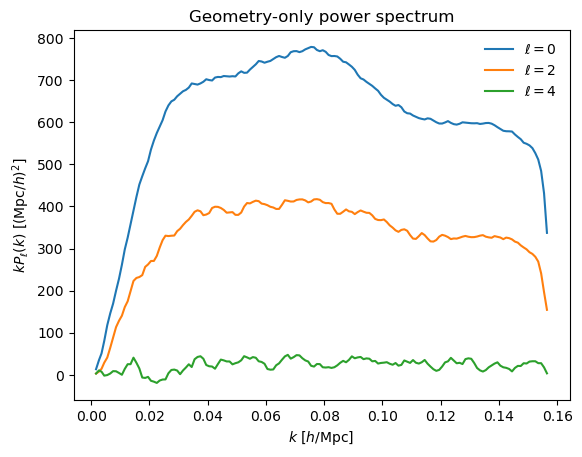

In [11]:
lss.mean(list(map(sum, pks_geo))).plot()
plt.title("Geometry-only power spectrum")

In [12]:
pks_ric = [
    fw_jit(
        *fkp_fields,
        theory=theory,
        seed=jax.random.key(i * 3 + 87),
        los=LOS,
        unitary_amplitude=UNITARY_AMPLITUDE,
        ric_args=ric_args,
        amr_args=None,
        nam_args=None,
        fkp_norms=fkp_norms,
        binner=binner,
        estimator_weights="weight_FKP",
        data_regions=ric_args.data_regions,
        randoms_regions=ric_args.randoms_regions,
    )
    for i in tqdm(range(nreal_fw), desc="RIC forward modeling")
]

RIC forward modeling: 100%|██████████| 20/20 [00:38<00:00,  1.91s/it]


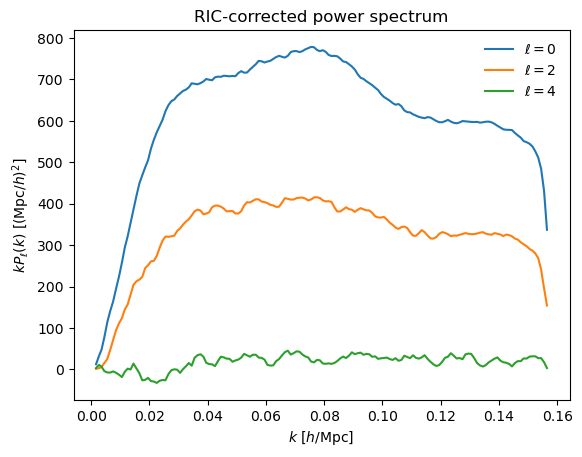

In [13]:
lss.mean(list(map(sum, pks_ric))).plot()
plt.title("RIC-corrected power spectrum");

Text(0.5, 0.98, 'RIC effect on power spectrum')

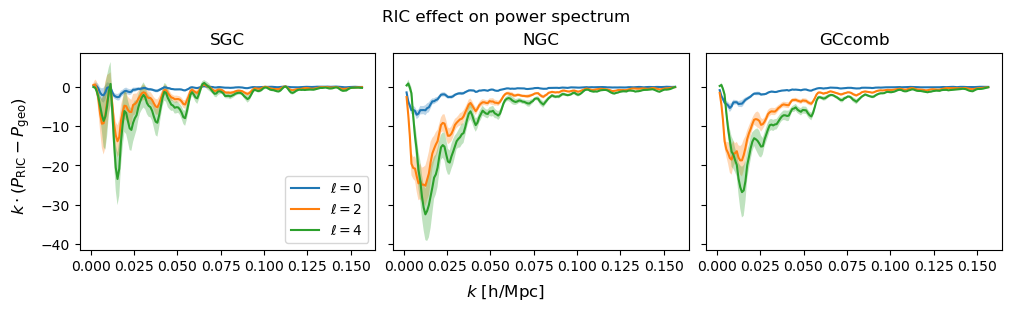

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=True, sharex=True, layout="constrained")


avg_effect_ric = [lss.mean([pk_ric.clone(value=pk_ric.value() - pk_geo.value()) for pk_geo, pk_ric in zip(pks_geo_group, pks_ric_group)]) for pks_geo_group, pks_ric_group in zip(zip(*pks_geo), zip(*pks_ric))]
cov_effect_ric = [lss.cov([pk_ric.clone(value=pk_ric.value() - pk_geo.value()) for pk_geo, pk_ric in zip(pks_geo_group, pks_ric_group)]) for pks_geo_group, pks_ric_group in zip(zip(*pks_geo), zip(*pks_ric))]

for isurvey, (ax, nsurvey) in enumerate(zip(axes, ["SGC", "NGC"], strict=False)):
    for ell in [0, 2, 4]:
        pole = avg_effect_ric[isurvey].get(ell)
        std = cov_effect_ric[isurvey].at.observable.get(ell).std().real / np.sqrt(nreal_fw)
        k = pole.coords("k")
        ax.plot(k, k * pole.value(), label=f"$\\ell = ${ell}")
        ax.fill_between(k, k * (pole.value() - std), k * (pole.value() + std), alpha=0.3)
    ax.set_title(nsurvey)

ax = axes[2]
cov = lss.cov([pk_ric[0].clone(value=sum(pk_ric).value() - sum(pk_geo).value()) for pk_geo, pk_ric in zip(pks_geo, pks_ric)])
for ell in [0, 2, 4]:
    pole = (avg_effect_ric[0] + avg_effect_ric[1]).get(ell)
    std = cov.at.observable.get(ell).std().real / np.sqrt(nreal_fw)
    k = pole.coords("k")
    ax.plot(k, k * pole.value(), label=f"$\\ell = ${ell}")
    ax.fill_between(k, k * (pole.value() - std), k * (pole.value() + std), alpha=0.3)
ax.set_title("GCcomb")

axes[0].legend()
fig.supxlabel("$k$ [h/Mpc]")
fig.supylabel(r"$k \cdot (P_\mathrm{RIC} - P_\mathrm{geo})$")
fig.suptitle("RIC effect on power spectrum")

## Forward modeling with and without AMR

In [15]:
pks_amr = [
    fw_jit(
        *fkp_fields,
        theory=theory,
        seed=jax.random.key(i * 3 + 87),
        los=LOS,
        unitary_amplitude=UNITARY_AMPLITUDE,
        ric_args=ric_args,
        amr_args=amr_args,
        nam_args=None,
        fkp_norms=fkp_norms,
        binner=binner,
        estimator_weights="weight_FKP",
        data_regions=ric_args.data_regions,
        randoms_regions=ric_args.randoms_regions,
    )
    for i in tqdm(range(nreal_fw), desc="AMR forward modeling")
]

AMR forward modeling: 100%|██████████| 20/20 [00:46<00:00,  2.31s/it]


Text(0.5, 1.0, 'AMR-corrected power spectrum')

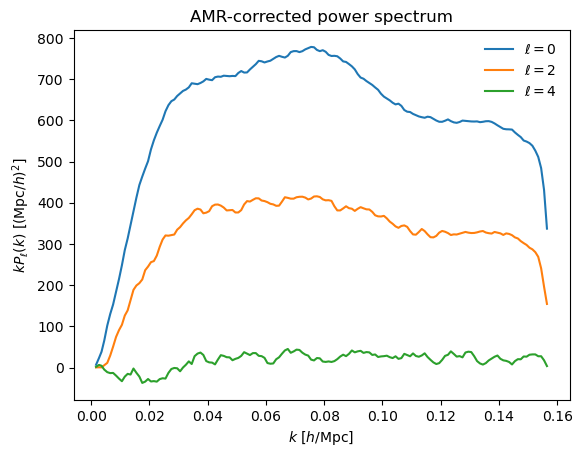

In [16]:
lss.mean(list(map(sum, pks_amr))).plot()
plt.title("AMR-corrected power spectrum")

Text(0.5, 0.98, 'AMR effect on power spectrum')

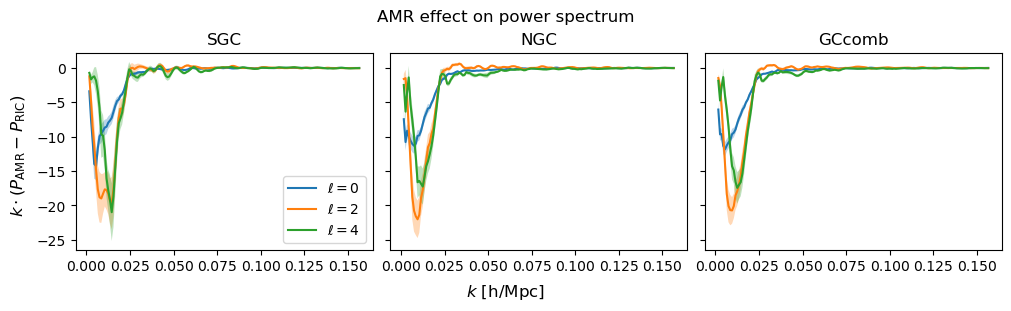

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=True, sharex=True, layout="constrained")

avg_effect_amr = [lss.mean([pk_amr.clone(value=pk_amr.value() - pk_ric.value()) for pk_ric, pk_amr in zip(pks_ric_group, pks_amr_group)]) for pks_ric_group, pks_amr_group in zip(zip(*pks_ric), zip(*pks_amr))]
cov_effect_amr = [lss.cov([pk_amr.clone(value=pk_amr.value() - pk_ric.value()) for pk_ric, pk_amr in zip(pks_ric_group, pks_amr_group)]) for pks_ric_group, pks_amr_group in zip(zip(*pks_ric), zip(*pks_amr))]

for isurvey, (ax, nsurvey) in enumerate(zip(axes, ["SGC", "NGC"], strict=False)):
    for ell in [0, 2, 4]:
        pole = avg_effect_amr[isurvey].get(ell)
        std = cov_effect_amr[isurvey].at.observable.get(ell).std().real / np.sqrt(nreal_fw)
        k = pole.coords("k")
        ax.plot(k, k * pole.value(), label=f"$\\ell = ${ell}")
        ax.fill_between(k, k * (pole.value() - std), k * (pole.value() + std), alpha=0.3)
    ax.set_title(nsurvey)

ax = axes[2]
cov = lss.cov([pk_amr[0].clone(value=sum(pk_amr).value() - sum(pk_ric).value()) for pk_ric, pk_amr in zip(pks_ric, pks_amr)])
for ell in [0, 2, 4]:
    pole = (avg_effect_amr[0] + avg_effect_amr[1]).get(ell)
    std = cov.at.observable.get(ell).std().real / np.sqrt(nreal_fw)
    k = pole.coords("k")
    ax.plot(k, k * pole.value(), label=f"$\\ell = ${ell}")
    ax.fill_between(k, k * (pole.value() - std), k * (pole.value() + std), alpha=0.3)
ax.set_title("GCcomb")

axes[0].legend()
fig.supxlabel("$k$ [h/Mpc]")
fig.supylabel(r"$k \cdot (P_\mathrm{AMR} - P_\mathrm{RIC})$")
fig.suptitle("AMR effect on power spectrum")
# ax.set_xscale("log")

Text(0.5, 0.98, 'AMR effect on power spectrum')

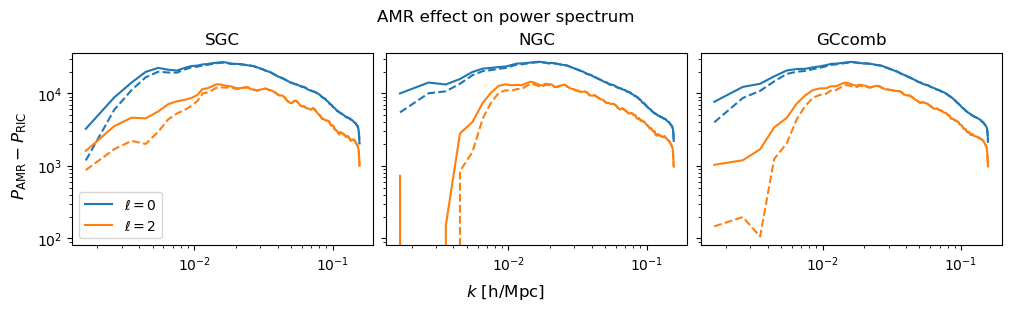

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=True, sharex=True, layout="constrained")

for isurvey, (ax, nsurvey) in enumerate(zip(axes, ["SGC", "NGC"], strict=False)):
    for ell in [0, 2]:
        pole_ric = lss.mean([pk_ric[isurvey] for pk_ric in pks_ric]).get(ell)
        pole_amr = lss.mean([pk_amr[isurvey] for pk_amr in pks_amr]).get(ell)
        k = pole_ric.coords("k")
        ax.plot(k, pole_ric.value(), color=f"C{ell // 2}", label=f"$\\ell = ${ell}")
        ax.plot(k, pole_amr.value(), color=f"C{ell // 2}", ls="--")
    ax.set_title(nsurvey)

ax = axes[2]
for ell in [0, 2]:
    pole_ric = lss.mean([sum(pk_ric) for pk_ric in pks_ric]).get(ell)
    pole_amr = lss.mean([sum(pk_amr) for pk_amr in pks_amr]).get(ell)
    k = pole_ric.coords("k")
    ax.plot(k, pole_ric.value(), color=f"C{ell // 2}", label=f"$\\ell = ${ell}")
    ax.plot(k, pole_amr.value(), color=f"C{ell // 2}", ls="--")
ax.set_title("GCcomb")

ax.loglog()
axes[0].legend()
fig.supxlabel("$k$ [h/Mpc]")
fig.supylabel(r"$P_\mathrm{AMR} - P_\mathrm{RIC}$")
fig.suptitle("AMR effect on power spectrum")


## Forward modeling with and without NAM

In [19]:
pks_nam = [
    fw_jit(
        *fkp_fields,
        theory=theory,
        seed=jax.random.key(i * 3 + 87),
        los=LOS,
        unitary_amplitude=UNITARY_AMPLITUDE,
        ric_args=ric_args,
        amr_args=None,
        nam_args=nam_args,
        fkp_norms=fkp_norms,
        binner=binner,
        estimator_weights="weight_FKP",
        data_regions=ric_args.data_regions,
        randoms_regions=ric_args.randoms_regions,
    )
    for i in tqdm(range(nreal_fw), desc="NAM forward modeling")
]

NAM forward modeling: 100%|██████████| 20/20 [00:38<00:00,  1.93s/it]


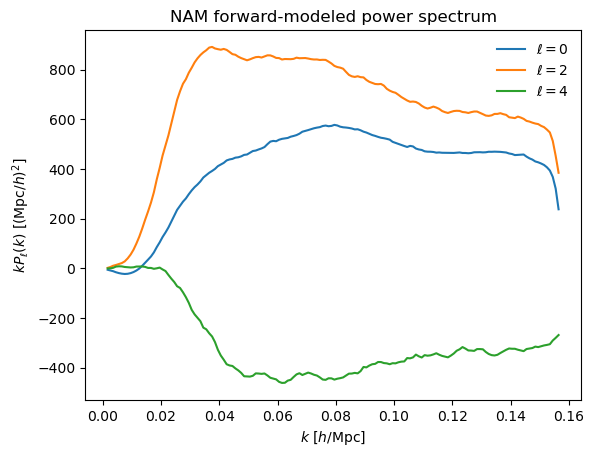

In [20]:
lss.mean(list(map(sum, pks_nam))).plot()
plt.title("NAM forward-modeled power spectrum")
plt.show()

Text(0.5, 0.98, 'NAM effect on power spectrum')

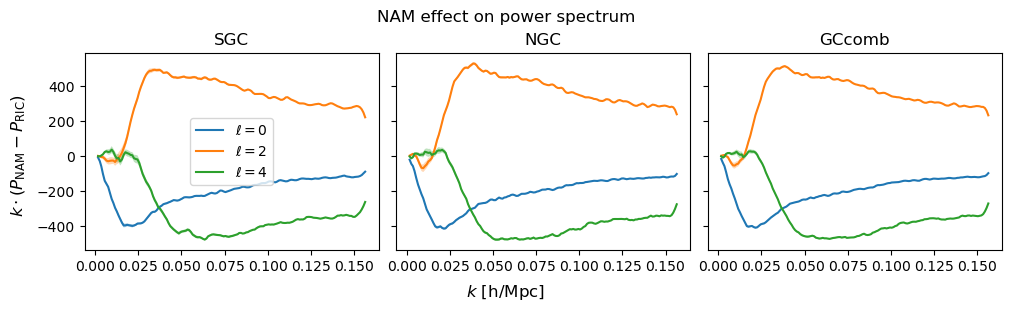

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=True, sharex=True, layout="constrained")

avg_effect_nam = [lss.mean([pk_nam.clone(value=pk_nam.value() - pk_ric.value()) for pk_ric, pk_nam in zip(pks_ric_group, pks_nam_group)]) for pks_ric_group, pks_nam_group in zip(zip(*pks_ric), zip(*pks_nam))]
cov_effect_nam = [lss.cov([pk_nam.clone(value=pk_nam.value() - pk_ric.value()) for pk_ric, pk_nam in zip(pks_ric_group, pks_nam_group)]) for pks_ric_group, pks_nam_group in zip(zip(*pks_ric), zip(*pks_nam))]

for isurvey, (ax, nsurvey) in enumerate(zip(axes, ["SGC", "NGC"], strict=False)):
    for ell in [0, 2, 4]:
        pole = avg_effect_nam[isurvey].get(ell)
        std = cov_effect_nam[isurvey].at.observable.get(ell).std().real / np.sqrt(nreal_fw)
        k = pole.coords("k")
        ax.plot(k, k * pole.value(), label=rf"$\ell = {{{ell}}}$")
        ax.fill_between(k, k * (pole.value() - std), k * (pole.value() + std), alpha=0.3)
    ax.set_title(nsurvey)

ax = axes[2]
cov = lss.cov([pk_nam[0].clone(value=sum(pk_nam).value() - sum(pk_ric).value()) for pk_ric, pk_nam in zip(pks_ric, pks_nam)])
for ell in [0, 2, 4]:
    pole = (avg_effect_nam[0] + avg_effect_nam[1]).get(ell)
    std = cov.at.observable.get(ell).std().real / np.sqrt(nreal_fw)
    k = pole.coords("k")
    ax.plot(k, k * pole.value(), label=rf"$\ell = {{{ell}}}$")
    ax.fill_between(k, k * (pole.value() - std), k * (pole.value() + std), alpha=0.3)
ax.set_title("GCcomb")

axes[0].legend()
fig.supxlabel("$k$ [h/Mpc]")
fig.supylabel(r"$k \cdot (P_\mathrm{NAM} - P_\mathrm{RIC})$")
fig.suptitle("NAM effect on power spectrum")